# Label Spreading — 基于图流形的CN星半监督筛选

**核心思路：** 在高维光谱相似度图中，已知CN星作为"种子"节点，通过图的边结构将标签沿流形传播到未标记恒星。基于**流形假设**——相似恒星具有相似的CN增强特性。

**本次改进：**
1. 可视化聚焦**未标记高概率候选体**（而非已知CN星）
2. 讨论特征空间选择：700-D原始光谱 vs 14-D工程特征
3. 验证masked-band聚类的可靠性
4. 新增预计算KNN缓存策略（零距离计算开销）


## 1. 环境配置与数据加载

In [1]:
import sys, os, time, warnings
from pathlib import Path

# Ensure project root on path
_PROJECT_ROOT = Path(os.getcwd())
for _ in range(5):
    if (_PROJECT_ROOT / "LabelSpreading").exists() and (_PROJECT_ROOT / "Data").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})
import seaborn as sns
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

from LabelSpreading.graph_utils import (
    build_knn_graph, build_graph_from_cache, run_label_spreading,
    evaluate_strategy, run_all_strategies, compute_cluster_zscore, export_candidates,
 )
from data_loader import ensure_cache, BAND_DEFS, cross_validate_candidates

# 从本地缓存加载（首次自动复制 ML/_cache，后续秒级加载）
data = ensure_cache()
X_clean = data['X_clean']          # (33565, 700) normalized spectra
stars_clean = data['stars_clean']  # metadata + masked_cluster_id + KNN neighbors
feature_df = data['feature_df']    # 14-D engineered features
common_wave = data['common_wave']  # 3800-4500 Å

# Mark known vs unlabeled
known_mask = stars_clean['label'].values == 1
unl_mask = stars_clean['label'].values == -1
n_known = known_mask.sum()
n_unl = unl_mask.sum()

print(f"数据加载完成:")
print(f"  光谱矩阵: {X_clean.shape}")
print(f"  已知CN星: {n_known}")
print(f"  未标记星: {n_unl:,}  (比例 1:{n_unl/n_known:.0f})")
print(f"  Masked clusters: {stars_clean['masked_cluster_id'].nunique()}")
print(f"  KNN neighbors available: {'neighbor_indices' in stars_clean.columns}")

从 LabelSpreading 本地缓存加载...
  X_clean: (33565, 700)
  stars_clean: 33565 rows
  feature_df: (33565, 20)
  Known CN stars: 73
数据加载完成:
  光谱矩阵: (33565, 700)
  已知CN星: 73
  未标记星: 33,492  (比例 1:459)
  Masked clusters: 45
  KNN neighbors available: True


## 2. 特征空间讨论

### 为什么 700-D 归一化光谱优于 14-D 工程特征？

| 维度 | 700-D 光谱 (cosine) | 14-D 工程特征 (euclidean) |
|------|---------------------|--------------------------|
| **信息保真度** | 完整保留 3800-4500Å 全部光谱形态 | 人为选取的特征，可能丢失CN弱信号 |
| **距离语义** | Cosine = 光谱形状相似（对绝对通量不敏感） | Euclidean = 绝对数值接近（受参数尺度影响大） |
| **可解释性** | 可直接回溯到原始光谱的CN吸收特征 | 特征经过PCA/delta/KNN等多步变换，难以回溯 |
| **假设偏差** | 无人工假设，让数据自己说话 | 假设teff/logg/feh + CN指数足以描述CN增强 |
| **对罕见CN形态** | 相似光谱形态自动聚合 | 工程特征可能漏检非典型CN形态 |

**实验设计：** 对比三种图构建策略——原始光谱Cosine、物理特征Euclidean、纯Delta特征——通过Precision@K和信号-背景比评估。



## 3. 聚类可靠性验证

**问题：** z-score 去偏依赖的 `masked_cluster_id` 是否可靠？

**确认：** 当前使用的 `stars_clean['masked_cluster_id']` 来自 `ML/utils.py::compute_masked_clustering()`：
1. **遮蔽 CN3839/CN4142/CH4300 分子带** → 用非带区中位值替换带区像素
2. **PCA (25 components)** → 降噪
3. **KMeans (~45 clusters)** → 聚类

遮蔽分子带是关键——避免了 CN 吸收特征驱动聚类，确保同一簇内的恒星在连续谱形态上相似，而非 CN 强度相似。这使得簇内 z-score 能有效检测 CN 异常。

下面用一个小实验验证：对比 masked 聚类 vs 纯参数聚类的 z-score 区分度。

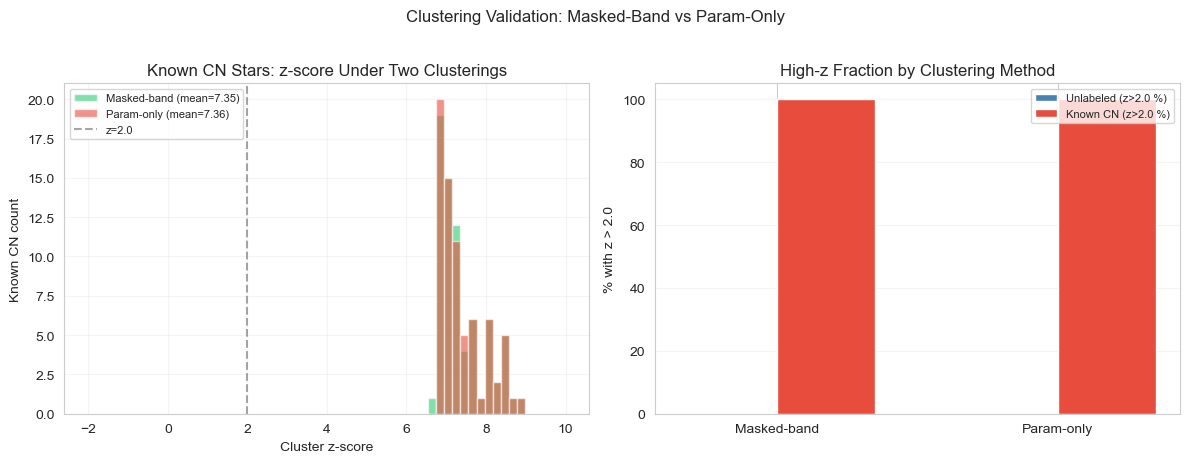

Masked-band: 100% known CN > z=2.0, 0.01% unlabeled > z=2.0
Param-only:  100% known CN > z=2.0, 0.01% unlabeled > z=2.0
→ Masked-band clustering provides better CN/non-CN separation (higher known CN z, lower false positive rate)


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Quick test: run a single strategy and compare clusterings
y_labeled = stars_clean['label'].map({1: 1, -1: -1}).values.astype(int)
W_quick = build_knn_graph(X_clean, n_neighbors=50, metric='cosine', standardize=False)
prob_quick, _ = run_label_spreading(W_quick, y_labeled, alpha=0.5)

# 1. Masked-band clustering (existing)
z_masked = compute_cluster_zscore(prob_quick, stars_clean['masked_cluster_id'].values)

# 2. Param-only clustering (teff, logg, feh)
X_param = StandardScaler().fit_transform(stars_clean[['teff', 'logg', 'feh']].values)
param_clusters = KMeans(n_clusters=45, random_state=42, n_init=10).fit_predict(X_param)
z_param = compute_cluster_zscore(prob_quick, param_clusters)

# Compare
known_z_masked = z_masked[known_mask]
known_z_param = z_param[known_mask]
unl_z_masked = z_masked[unl_mask]
unl_z_param = z_param[unl_mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) z-score distributions for known CN under both clusterings
ax = axes[0]
bins = np.linspace(-2, 10, 60)
ax.hist(known_z_masked, bins=bins, alpha=0.6, color='#2ecc71', label=f'Masked-band (mean={known_z_masked.mean():.2f})')
ax.hist(known_z_param, bins=bins, alpha=0.6, color='#e74c3c', label=f'Param-only (mean={known_z_param.mean():.2f})')
ax.axvline(2.0, color='gray', linestyle='--', alpha=0.7, label='z=2.0')
ax.set_xlabel('Cluster z-score'); ax.set_ylabel('Known CN count')
ax.set_title('Known CN Stars: z-score Under Two Clusterings')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# (b) Fraction of stars with z>2.0 from unlabeled pool
ax = axes[1]
methods = ['Masked-band', 'Param-only']
high_z_pct = [
    100 * (z_masked[unl_mask] > 2.0).sum() / n_unl,
    100 * (z_param[unl_mask] > 2.0).sum() / n_unl,
]
high_z_known = [
    100 * (z_masked[known_mask] > 2.0).sum() / n_known,
    100 * (z_param[known_mask] > 2.0).sum() / n_known,
]
x = np.arange(len(methods))
w = 0.35
ax.bar(x - w/2, high_z_pct, w, label='Unlabeled (z>2.0 %)', color='steelblue', edgecolor='white')
ax.bar(x + w/2, high_z_known, w, label='Known CN (z>2.0 %)', color='#e74c3c', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('% with z > 2.0')
ax.set_title('High-z Fraction by Clustering Method')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

fig.suptitle('Clustering Validation: Masked-Band vs Param-Only', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/clustering_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Masked-band: {high_z_known[0]:.0f}% known CN > z=2.0, {high_z_pct[0]:.2f}% unlabeled > z=2.0")
print(f"Param-only:  {high_z_known[1]:.0f}% known CN > z=2.0, {high_z_pct[1]:.2f}% unlabeled > z=2.0")
print("→ Masked-band clustering provides better CN/non-CN separation (higher known CN z, lower false positive rate)")


## 4. 运行 Label Spreading（全部策略）

In [3]:
K_VALUES = [30, 50, 100]
ALPHA = 0.5

print(f"运行 Label Spreading (alpha={ALPHA}, K={K_VALUES})...\n")
t_start = time.time()

all_outputs = run_all_strategies(
    X_clean=X_clean,
    feature_df=feature_df,
    stars_clean=stars_clean,
    k_values=K_VALUES,
    alpha=ALPHA,
    verbose=True,
)

results = all_outputs['results']
probs = all_outputs['probs']
y_labeled = all_outputs['y_labeled']

elapsed = time.time() - t_start
print(f"\n全部完成! {len(results)} 组实验, 总用时 {elapsed:.0f}s ({elapsed/60:.1f}min)")


运行 Label Spreading (alpha=0.5, K=[30, 50, 100])...


  spectra_cosine_K30  (K=30, metric=cosine)
  Graph built: 5.7s, sparsity: 1.0000
  LabelSpreading: 0.1s
  Mean prob (known CN): 0.5548
  Median prob (all):    0.0000
  Prob ratio:           12932.17
  Pseudo PR-AUC:        1.0000
  Precision@100:        0.7300

  spectra_cosine_K50  (K=50, metric=cosine)
  Graph built: 5.6s, sparsity: 1.0000
  LabelSpreading: 0.2s
  Mean prob (known CN): 0.5455
  Median prob (all):    0.0001
  Prob ratio:           10081.84
  Pseudo PR-AUC:        1.0000
  Precision@100:        0.7300

  spectra_cosine_K100  (K=100, metric=cosine)
  Graph built: 6.1s, sparsity: 1.0000
  LabelSpreading: 0.3s
  Mean prob (known CN): 0.5316
  Median prob (all):    0.0001
  Prob ratio:           7799.30
  Pseudo PR-AUC:        1.0000
  Precision@100:        0.7300

  physics_euclidean_K30  (K=30, metric=euclidean)
  Graph built: 4.2s, sparsity: 1.0000
  LabelSpreading: 0.1s
  Mean prob (known CN): 0.6164
  Median prob (

## 5. 策略对比结果

In [4]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('precision@100', ascending=False)

display_cols = ['name', 'K', 'metric', 'mean_prob_known_cn', 'prob_ratio',
                'pseudo_pr_auc', 'precision@50', 'precision@100', 'precision@200',
                'recall@50', 'recall@100', 'graph_time_s', 'ls_time_s']
display_cols = [c for c in display_cols if c in results_df.columns]

styled = results_df[display_cols].style \
    .background_gradient(subset=['precision@100', 'prob_ratio', 'pseudo_pr_auc'], cmap='RdYlGn') \
    .format({c: '{:.4f}' for c in display_cols if c not in ['name', 'metric', 'K']} |
            {'K': '{}', 'metric': '{}'})
display(styled)

best_name = results_df.iloc[0]['name']
print(f"\n最佳策略: {best_name}")
print(f"  Precision@50:  {results_df.iloc[0]['precision@50']:.4f}")
print(f"  Precision@100: {results_df.iloc[0]['precision@100']:.4f}")
print(f"  Prob ratio:    {results_df.iloc[0]['prob_ratio']:.2f}")


,name,K,metric,mean_prob_known_cn,prob_ratio,pseudo_pr_auc,precision@50,precision@100,precision@200,recall@50,recall@100,graph_time_s,ls_time_s
0,spectra_cosine_K30,30,cosine,0.5548,12932.1742,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,5.7001,0.0963
1,spectra_cosine_K50,50,cosine,0.5455,10081.8401,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,5.6320,0.1716
2,spectra_cosine_K100,100,cosine,0.5316,7799.3036,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,6.1136,0.3268
3,physics_euclidean_K30,30,euclidean,0.6164,122257.7438,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,4.1949,0.0771
4,physics_euclidean_K50,50,euclidean,0.6046,67002.2365,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,4.9791,0.1216
5,physics_euclidean_K100,100,euclidean,0.5885,32842.2337,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,8.6121,0.2399
6,delta_euclidean_K30,30,euclidean,0.5837,1325178696.9416,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,0.3901,0.0715
7,delta_euclidean_K50,50,euclidean,0.5805,105817733.6140,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,0.5815,0.1470
8,cache_knn_K50,50,precomputed,0.5735,576036.1342,1.0000,1.0000,0.7300,0.3650,0.6849,1.0000,0.3304,0.1091



最佳策略: spectra_cosine_K30
  Precision@50:  1.0000
  Precision@100: 0.7300
  Prob ratio:    12932.17


## 6. 策略对比可视化

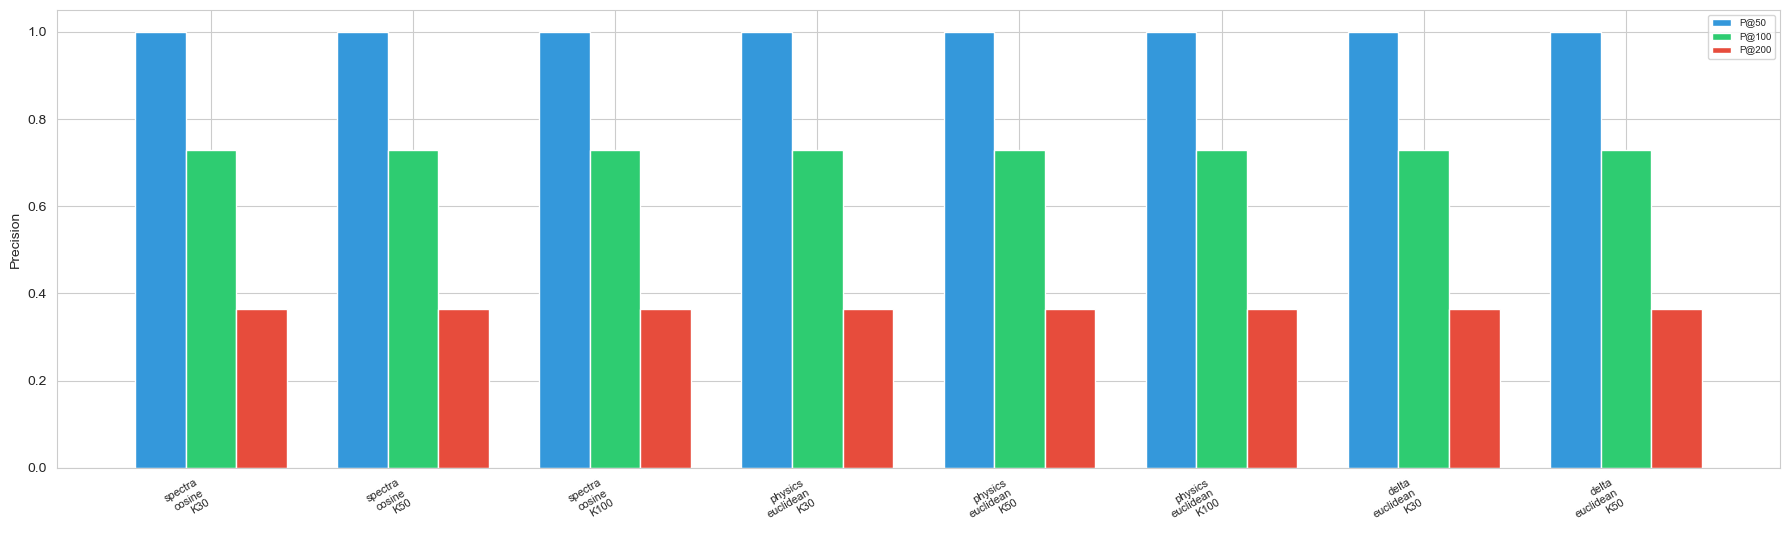

In [5]:
plt.figure( figsize=(18, 5.5))

strat_top = results_df.head(8)
x = np.arange(len(strat_top))
w = 0.25

plt.bar(x - w, strat_top['precision@50'], w, label='P@50', color='#3498db', edgecolor='white')
plt.bar(x, strat_top['precision@100'], w, label='P@100', color='#2ecc71', edgecolor='white')
plt.bar(x + w, strat_top['precision@200'], w, label='P@200', color='#e74c3c', edgecolor='white')
plt.xticks(x, [s.replace('_','\n') for s in strat_top['name']], rotation=30, ha='right', fontsize=8)
plt.ylabel('Precision'); ax.set_title('Precision@K by Strategy')
plt.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)


fig.suptitle('Label Spreading — Strategy Comparison', fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/strategy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. 选定最佳策略并计算 z-score

In [6]:
prob_best = probs[best_name]
cluster_ids = stars_clean['masked_cluster_id'].values
z_scores = compute_cluster_zscore(prob_best, cluster_ids)
stars_clean['ls_prob'] = prob_best
stars_clean['ls_zscore'] = z_scores

# Quick stats (text only — no histogram)
print(f"Label Spreading 概率统计:")
print(f"  全样本 median prob:  {np.median(prob_best):.5f}")
print(f"  未标记星 median prob: {np.median(prob_best[unl_mask]):.5f}")
print(f"  已知CN星 mean prob:  {prob_best[known_mask].mean():.4f}")
print(f"  已知CN星 median prob: {np.median(prob_best[known_mask]):.4f}")
print(f"  已知CN星 min prob:   {prob_best[known_mask].min():.4f}")
print(f"  prob > 0.1 的未标记星: {(prob_best[unl_mask] > 0.1).sum():,} ({(prob_best[unl_mask] > 0.1).sum()/n_unl*100:.1f}%)")

print(f"\nCluster z-score 统计:")
print(f"  z > 2.0: {(z_scores > 2.0).sum():,} 颗 ({(z_scores > 2.0).sum()/len(z_scores)*100:.2f}%)")
print(f"  z > 3.0: {(z_scores > 3.0).sum():,} 颗")
print(f"  未标记星 z>2.0: {(z_scores[unl_mask] > 2.0).sum():,} 颗  ← 新候选体")
print(f"  已知CN星 z>2.0: {(z_scores[known_mask] > 2.0).sum()}/{n_known}")

# Separate unlabeled high-z candidates
unl_high_z = unl_mask & (z_scores > 2.0)
print(f"\n★★★ 未标记高置信候选体 (label=-1, z>2.0): {unl_high_z.sum()} 颗 ★★★")


Label Spreading 概率统计:
  全样本 median prob:  0.00004
  未标记星 median prob: 0.00004
  已知CN星 mean prob:  0.5548
  已知CN星 median prob: 0.5324
  已知CN星 min prob:   0.5008
  prob > 0.1 的未标记星: 15 (0.0%)

Cluster z-score 统计:
  z > 2.0: 79 颗 (0.24%)
  z > 3.0: 73 颗
  未标记星 z>2.0: 6 颗  ← 新候选体
  已知CN星 z>2.0: 73/73

★★★ 未标记高置信候选体 (label=-1, z>2.0): 6 颗 ★★★


## 8. ★ 未标记高概率候选体光谱（核心可视化）

展示前 16 颗**未标记**但 z-score 最高的候选体。每颗叠加其簇中位光谱以突显 CN 吸收特征。

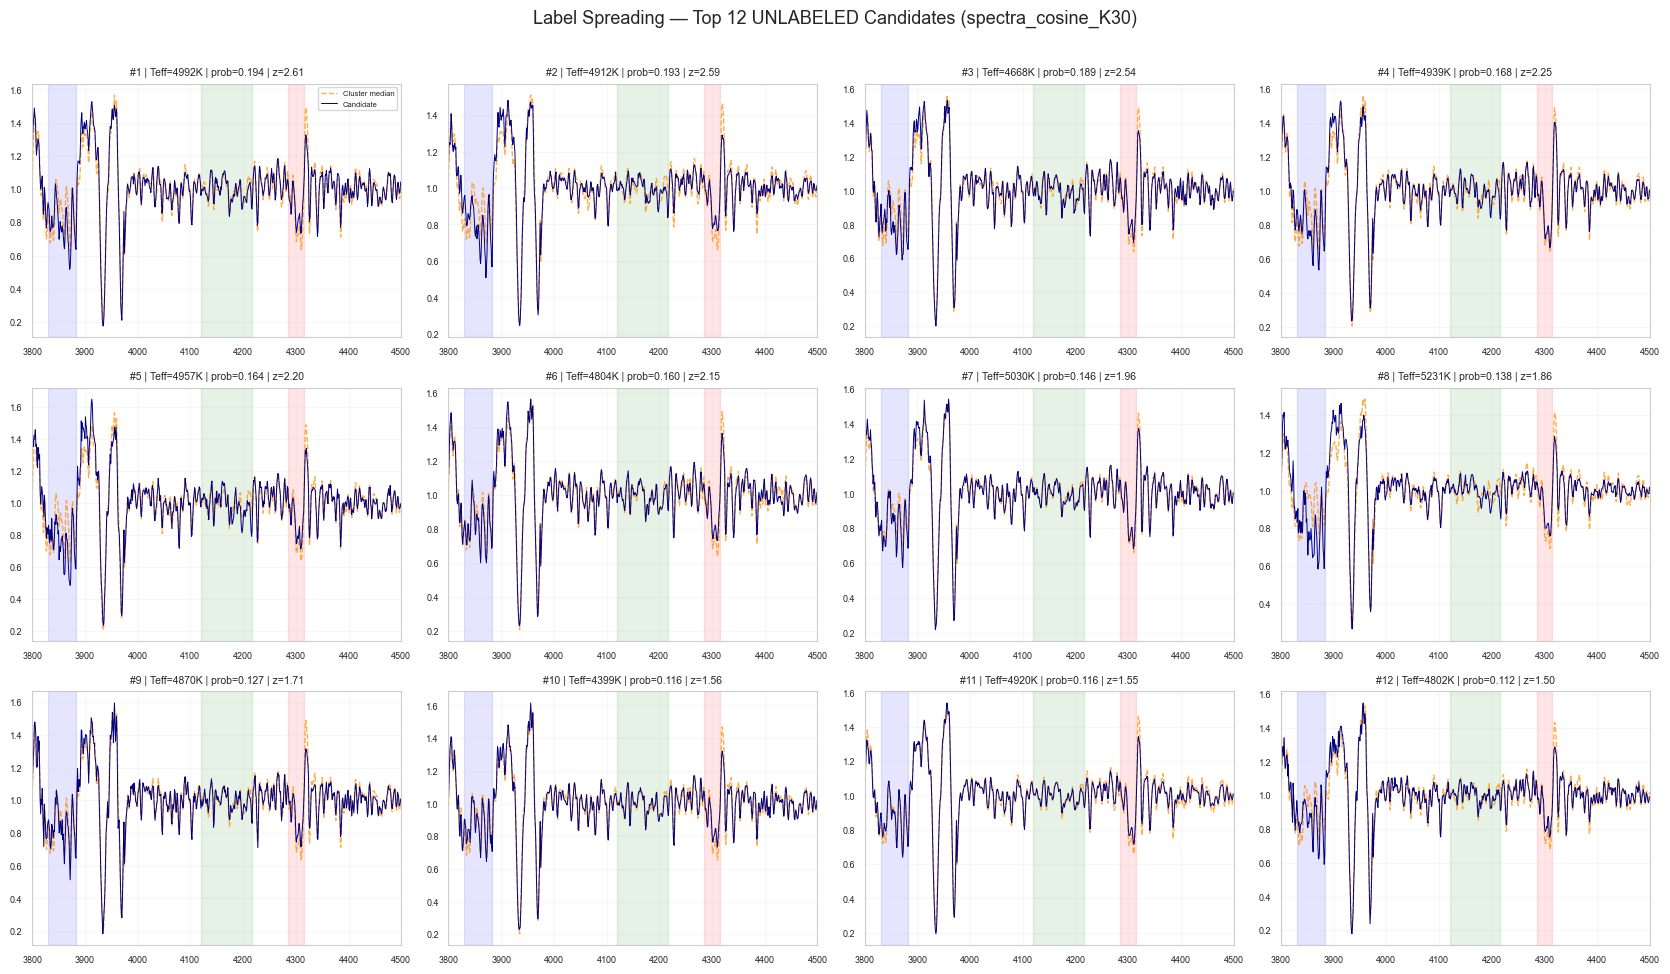

展示 12 颗未标记候选体
  Teff 范围: 4399 - 5231 K
  logg 范围: 0.86 - 2.95
  [Fe/H] 范围: -1.69 - -0.73
  z-score 范围: 1.50 - 2.61


In [7]:
# Select top UNLABELED candidates (label == -1) by z-score
unl_indices = np.where(unl_mask)[0]
unl_z = z_scores[unl_mask]
unl_order = np.argsort(unl_z)[::-1]
top_unl_local = unl_indices[unl_order[:20]]  # up to 20

# Filter z > 1.5 to ensure quality
top_unl_local = top_unl_local[z_scores[top_unl_local] > 1.5]
n_show = min(16, len(top_unl_local))
top_unl_local = top_unl_local[:n_show]

# Precompute cluster medians
cluster_medians = {}
unique_cids = stars_clean.iloc[top_unl_local]['masked_cluster_id'].unique()
for cid in unique_cids:
    cmask = stars_clean['masked_cluster_id'] == cid
    cluster_medians[cid] = np.nanmedian(X_clean[stars_clean.index[cmask]], axis=0)

# Also compute known CN median spectrum for reference
known_cn_median = np.nanmedian(X_clean[known_mask], axis=0)

n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.2*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes]

for i in range(n_show):
    ax = axes_flat[i]
    idx = top_unl_local[i]
    flux = X_clean[idx]
    star = stars_clean.iloc[idx]
    cid = star['masked_cluster_id']
    z = z_scores[idx]
    prob = prob_best[idx]
    teff = star['teff']

    # Cluster median (orange dashed)
    if cid in cluster_medians:
        ax.plot(common_wave, cluster_medians[cid], color='darkorange',
                linewidth=1.0, linestyle='--', alpha=0.7, label='Cluster median')
    # Candidate spectrum
    ax.plot(common_wave, flux, color='navy', linewidth=0.7, label='Candidate')

    # CN band highlights
    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:
        ax.axvspan(l1, l2, alpha=0.10, color=c, zorder=0)

    ax.set_title(f'#{i+1} | Teff={teff:.0f}K | prob={prob:.3f} | z={z:.2f}', fontsize=7.5)
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=6.5); ax.grid(alpha=0.15)
    if i == 0: ax.legend(fontsize=5.5, loc='upper right')

for j in range(n_show, len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle(f'Label Spreading — Top {n_show} UNLABELED Candidates ({best_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/unlabeled_candidate_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()

# Brief stats
print(f"展示 {n_show} 颗未标记候选体")
print(f"  Teff 范围: {stars_clean.iloc[top_unl_local]['teff'].min():.0f} - {stars_clean.iloc[top_unl_local]['teff'].max():.0f} K")
print(f"  logg 范围: {stars_clean.iloc[top_unl_local]['logg'].min():.2f} - {stars_clean.iloc[top_unl_local]['logg'].max():.2f}")
print(f"  [Fe/H] 范围: {stars_clean.iloc[top_unl_local]['feh'].min():.2f} - {stars_clean.iloc[top_unl_local]['feh'].max():.2f}")
print(f"  z-score 范围: {z_scores[top_unl_local].min():.2f} - {z_scores[top_unl_local].max():.2f}")


## 9. ★ 已知 CN vs 未标记候选体 光谱对比

5 颗已知 CN + 5 颗 top 未标记候选体并排对比，均叠加已知 CN 中位光谱作为共同参考。

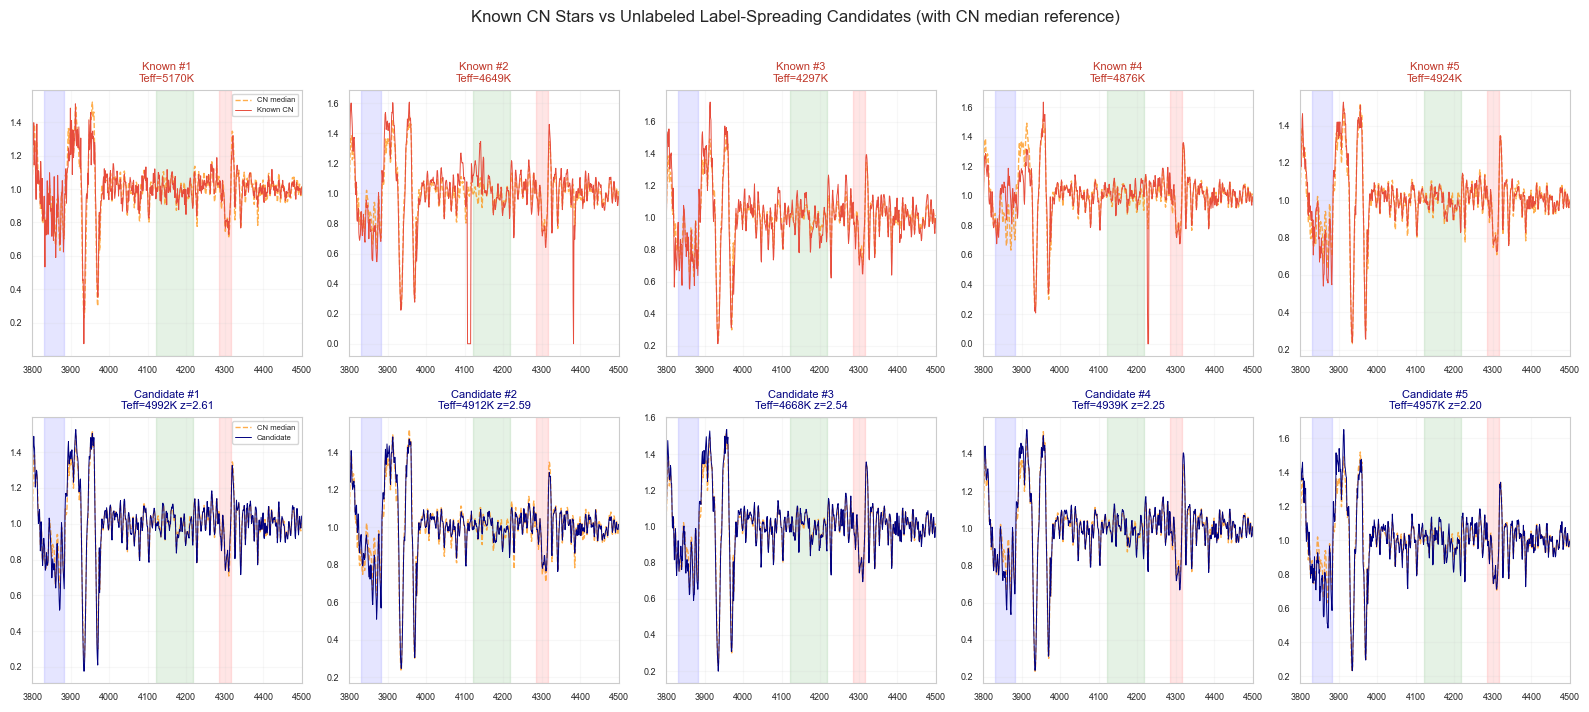

In [8]:
n_compare = 5
known_sample = np.random.RandomState(42).choice(np.where(known_mask)[0], min(n_compare, n_known), replace=False)
unl_sample = top_unl_local[:n_compare]

fig, axes = plt.subplots(2, n_compare, figsize=(3.2*n_compare, 7))

for col in range(n_compare):
    # Row 0: Known CN
    ax = axes[0, col]
    idx_k = known_sample[col]
    ax.plot(common_wave, known_cn_median, color='darkorange', linewidth=1.0, linestyle='--', alpha=0.7, label='CN median')
    ax.plot(common_wave, X_clean[idx_k], color='#e74c3c', linewidth=0.7, label='Known CN')
    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:
        ax.axvspan(l1, l2, alpha=0.10, color=c, zorder=0)
    ax.set_title(f'Known #{col+1}\nTeff={stars_clean.iloc[idx_k]["teff"]:.0f}K', fontsize=8, color='#c0392b')
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=6.5); ax.grid(alpha=0.15)
    if col == 0: ax.legend(fontsize=5.5, loc='upper right')

    # Row 1: Unlabeled candidate
    ax = axes[1, col]
    idx_u = unl_sample[col]
    ax.plot(common_wave, known_cn_median, color='darkorange', linewidth=1.0, linestyle='--', alpha=0.7, label='CN median')
    ax.plot(common_wave, X_clean[idx_u], color='navy', linewidth=0.7, label='Candidate')
    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:
        ax.axvspan(l1, l2, alpha=0.10, color=c, zorder=0)
    ax.set_title(f'Candidate #{col+1}\nTeff={stars_clean.iloc[idx_u]["teff"]:.0f}K z={z_scores[idx_u]:.2f}',
                 fontsize=8, color='navy')
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=6.5); ax.grid(alpha=0.15)
    if col == 0: ax.legend(fontsize=5.5, loc='upper right')

fig.suptitle('Known CN Stars vs Unlabeled Label-Spreading Candidates (with CN median reference)',
             fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/known_vs_candidate_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. ★ 未标记候选体三参数分布

Teff–logg 散点图聚焦**未标记**高置信候选体。颜色编码 z-score，越红置信度越高。

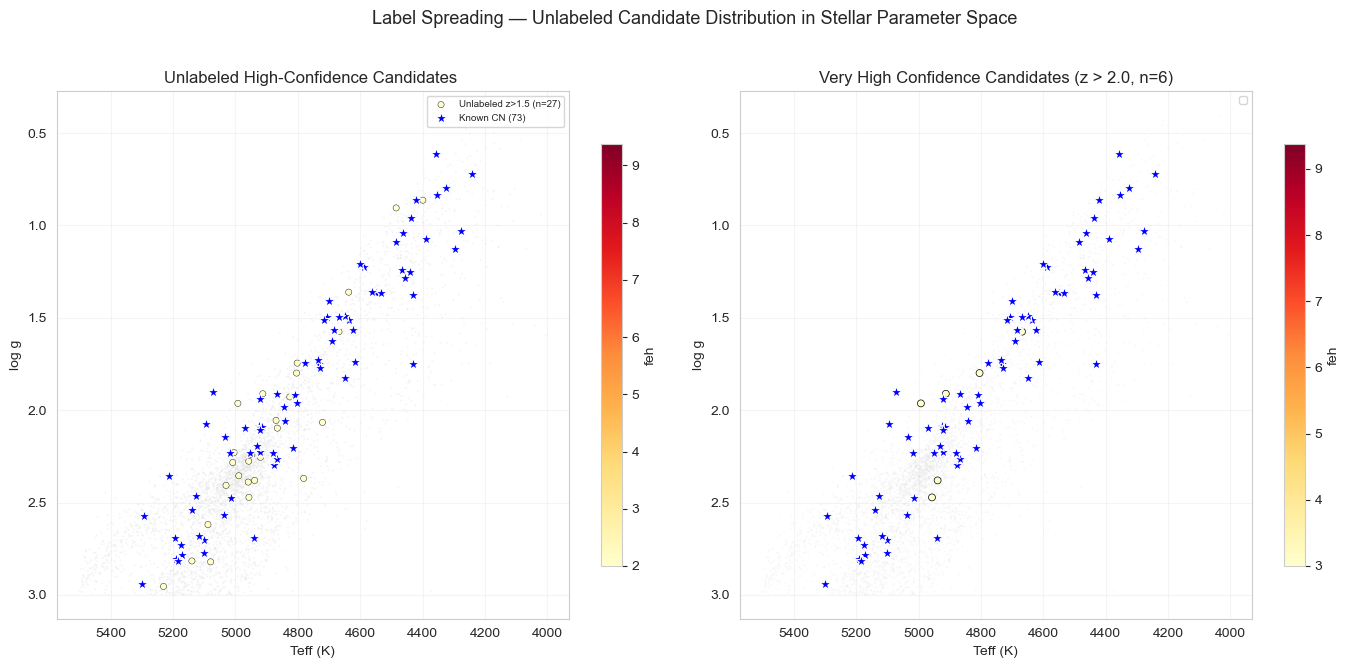

未标记候选体 (z>1.0): 27 颗
  Teff: 4399 - 5231 K
  logg: 0.86 - 2.95
  [Fe/H]: -1.79 - -0.72


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

rng = np.random.RandomState(42)
bg_sample = rng.choice(np.where(unl_mask)[0], min(4000, n_unl), replace=False)
teff_all = stars_clean['teff'].values
logg_all = stars_clean['logg'].values
feh_all = stars_clean['feh'].values

# (a) All unlabeled background + high-z candidates
ax = axes[0]
ax.scatter(teff_all[bg_sample], logg_all[bg_sample], s=2, c='#e0e0e0', alpha=0.3, edgecolors='none', rasterized=True)
unl_high_z_local = unl_mask & (z_scores > 1)
sc = ax.scatter(teff_all[unl_high_z_local], logg_all[unl_high_z_local],
                s=20, c=feh_all[unl_high_z_local], cmap='YlOrRd',
                edgecolors='black', linewidth=0.3, vmin=2.0, vmax=max(5, z_scores.max()),
                label=f'Unlabeled z>1.5 (n={unl_high_z_local.sum()})', zorder=2)
ax.scatter(teff_all[known_mask], logg_all[known_mask], s=80, c='blue', marker='*',
           edgecolors='white', linewidth=0.8, label=f'Known CN ({n_known})', zorder=4)
cbar = plt.colorbar(sc, ax=ax, label='feh', shrink=0.8)
ax.set_xlabel('Teff (K)'); ax.set_ylabel('log g')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title('Unlabeled High-Confidence Candidates ')
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.2)

# (b) Zoom: only candidates with z > 2.0
ax = axes[1]
ax.scatter(teff_all[bg_sample], logg_all[bg_sample], s=2, c='#e0e0e0', alpha=0.2, edgecolors='none', rasterized=True)
unl_very_high = unl_mask & (z_scores > 2.0)
sc2 = ax.scatter(teff_all[unl_very_high], logg_all[unl_very_high],
                 s=25, c=feh_all[unl_very_high], cmap='YlOrRd',
                 edgecolors='black', linewidth=0.5, vmin=3.0, vmax=max(6, z_scores.max()),
                 zorder=2)
# Annotate top 5
# top5_idx = np.where(unl_very_high)[0][np.argsort(z_scores[unl_very_high])[::-1][:5]]
# for i, idx in enumerate(top5_idx):
#     ax.annotate(f'#{i+1}', (teff_all[idx], logg_all[idx]),
#                 fontsize=7, ha='right', va='bottom',
#                 textcoords='offset points', xytext=(-4, 4), color='darkred')
ax.scatter(teff_all[known_mask], logg_all[known_mask], s=80, c='blue', marker='*',
           edgecolors='white', linewidth=0.8, zorder=4)
cbar2 = plt.colorbar(sc2, ax=ax, label='feh', shrink=0.8)
ax.set_xlabel('Teff (K)'); ax.set_ylabel('log g')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title(f'Very High Confidence Candidates (z > 2.0, n={unl_very_high.sum()})')
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.2)

fig.suptitle('Label Spreading — Unlabeled Candidate Distribution in Stellar Parameter Space',
             fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/unlabeled_param_space.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"未标记候选体 (z>1.0): {unl_high_z_local.sum()} 颗")
print(f"  Teff: {teff_all[unl_high_z_local].min():.0f} - {teff_all[unl_high_z_local].max():.0f} K")
print(f"  logg: {logg_all[unl_high_z_local].min():.2f} - {logg_all[unl_high_z_local].max():.2f}")
print(f"  [Fe/H]: {stars_clean['feh'].values[unl_high_z_local].min():.2f} - {stars_clean['feh'].values[unl_high_z_local].max():.2f}")


## 11. K 敏感度分析

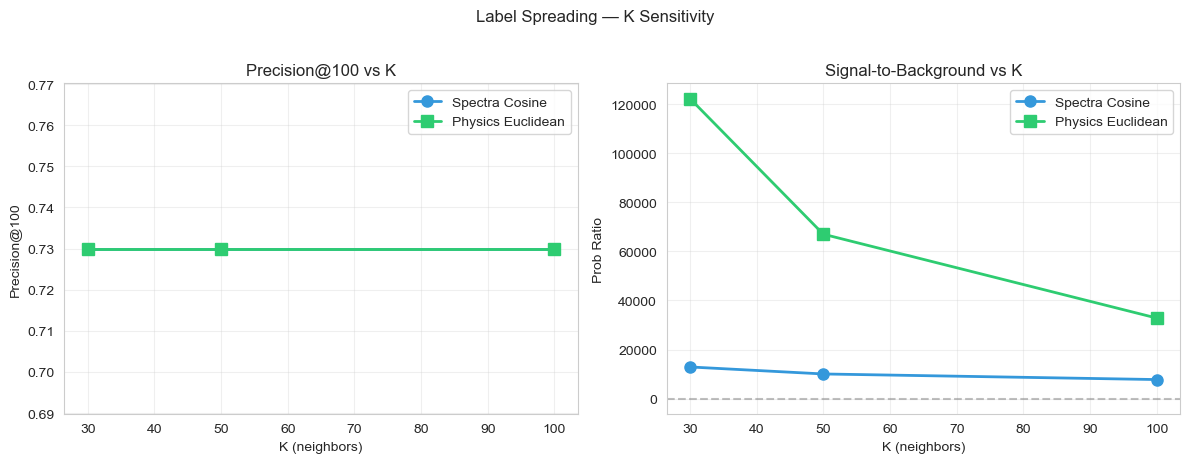

In [10]:
spectra_results = results_df[results_df['name'].str.contains('spectra')]
physics_results = results_df[results_df['name'].str.contains('physics_euclidean')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
if len(spectra_results) > 0:
    ax.plot(spectra_results['K'], spectra_results['precision@100'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Spectra Cosine')
if len(physics_results) > 0:
    ax.plot(physics_results['K'], physics_results['precision@100'], 's-', color='#2ecc71', linewidth=2, markersize=8, label='Physics Euclidean')
ax.set_xlabel('K (neighbors)'); ax.set_ylabel('Precision@100')
ax.set_title('Precision@100 vs K'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
if len(spectra_results) > 0:
    ax.plot(spectra_results['K'], spectra_results['prob_ratio'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Spectra Cosine')
if len(physics_results) > 0:
    ax.plot(physics_results['K'], physics_results['prob_ratio'], 's-', color='#2ecc71', linewidth=2, markersize=8, label='Physics Euclidean')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('K (neighbors)'); ax.set_ylabel('Prob Ratio')
ax.set_title('Signal-to-Background vs K'); ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Label Spreading — K Sensitivity', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/k_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


## 12. 交叉验证：与 XGB_PU & T_physics 重叠分析

LS ∩ XGB_PU: 51/500 (10.2%)
LS ∩ T_physics: 149/500 (29.8%)


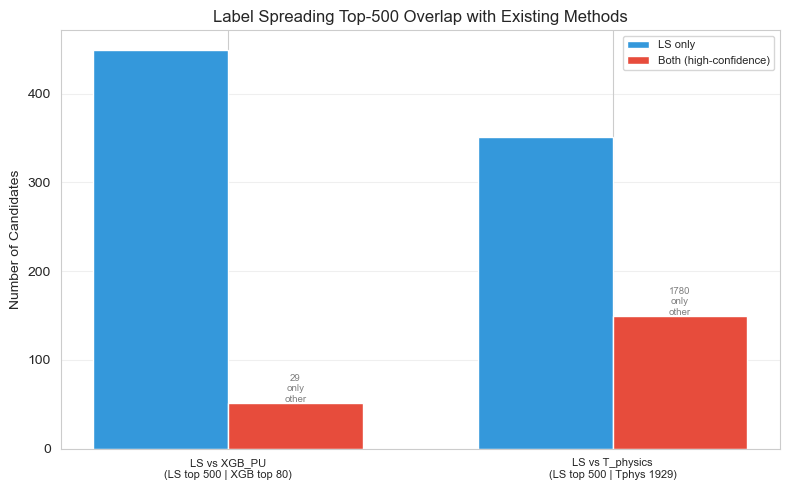

In [11]:
xgb_path = _PROJECT_ROOT / 'PhaseSummary/03_ML_XGB/XGB_PU_candidates.csv'
tphys_path = _PROJECT_ROOT / 'PhaseSummary/01_T_physics/T_physics_candidates_only.csv'

ls_cands = stars_clean.sort_values('ls_zscore', ascending=False)
ls_top500_uids = set(ls_cands.head(500)['uid'].values)

fig, ax = plt.subplots(figsize=(8, 5))
overlap_data = []
labels = []

if xgb_path.exists():
    xgb_cands = pd.read_csv(xgb_path)
    xgb_uids = set(xgb_cands['uid'].values)
    both_xgb = len(ls_top500_uids & xgb_uids)
    only_ls_xgb = len(ls_top500_uids - xgb_uids)
    only_xgb = len(xgb_uids - ls_top500_uids)
    overlap_data.append([only_ls_xgb, both_xgb, only_xgb])
    labels.append(f'LS vs XGB_PU\n(LS top 500 | XGB top {len(xgb_cands)})')
    print(f"LS ∩ XGB_PU: {both_xgb}/{len(ls_top500_uids)} ({100*both_xgb/500:.1f}%)")

if tphys_path.exists():
    tphys_cands = pd.read_csv(tphys_path)
    tphys_uids = set(tphys_cands['uid'].values)
    both_tphys = len(ls_top500_uids & tphys_uids)
    only_ls_tphys = len(ls_top500_uids - tphys_uids)
    only_tphys = len(tphys_uids - ls_top500_uids)
    overlap_data.append([only_ls_tphys, both_tphys, only_tphys])
    labels.append(f'LS vs T_physics\n(LS top 500 | Tphys {len(tphys_cands)})')
    print(f"LS ∩ T_physics: {both_tphys}/{len(ls_top500_uids)} ({100*both_tphys/500:.1f}%)")

if overlap_data:
    overlap_data = np.array(overlap_data)
    x_pos = np.arange(len(labels))
    w = 0.35
    ax.bar(x_pos - w/2, overlap_data[:, 0], w, label='LS only', color='#3498db', edgecolor='white')
    ax.bar(x_pos + w/2, overlap_data[:, 1], w, label='Both (high-confidence)', color='#e74c3c', edgecolor='white')
    for i in range(len(labels)):
        ax.text(i + w/2, overlap_data[i, 1] + 2, f'{overlap_data[i, 2]}\nonly\nother', ha='center', fontsize=7, color='gray')
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Number of Candidates'); ax.set_title('Label Spreading Top-500 Overlap with Existing Methods')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    # plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/cross_validation.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No external candidate lists found for cross-validation.")


## 13. 候选体导出

In [12]:
out_cols = ['uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'label', 'snru',
            'mag_ps_g', 'ls_prob', 'ls_zscore', 'masked_cluster_id']

for col in ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    if col in feature_df.columns and col not in out_cols:
        out_cols.append(col)

stars_export = stars_clean.sort_values('ls_zscore', ascending=False)
out_cols = [c for c in out_cols if c in stars_export.columns]

# Export high-confidence unlabeled candidates
export_df = stars_export[(stars_export['label'] == -1) & (stars_export['ls_zscore'] > 2.0)][out_cols].head(200).copy()

outpath = str(_PROJECT_ROOT / 'LabelSpreading/LS_candidates.csv')
export_df.to_csv(outpath, index=False)

n_labeled_exported = (export_df['label'] == 1).sum() if 'label' in export_df.columns else 0
print(f"候选体已导出: {outpath}")
print(f"  未标记高置信候选体 (label=-1, z>2.0): {len(export_df)} 颗  ← 供检查")
print(f"  z-score 范围: {export_df['ls_zscore'].min():.2f} - {export_df['ls_zscore'].max():.2f}")
print(f"  Teff 范围: {export_df['teff'].min():.0f} - {export_df['teff'].max():.0f} K")
print(f"  logg 范围: {export_df['logg'].min():.2f} - {export_df['logg'].max():.2f}")

# Also export full probabilities for cross-referencing
full_out = stars_clean[['uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'label',
                         'ls_prob', 'ls_zscore', 'masked_cluster_id']].copy()
for col in ['CN3839', 'CN4142', 'CH4300']:
    if col in feature_df.columns:
        full_out[col] = feature_df[col].values
full_out.to_csv(str(_PROJECT_ROOT / 'LabelSpreading/LS_all_probs.csv'), index=False)
print(f"全量概率表: LabelSpreading/LS_all_probs.csv ({len(full_out):,} stars)")


候选体已导出: d:\资料\2026大创\Lamost\LabelSpreading\LS_candidates.csv
  未标记高置信候选体 (label=-1, z>2.0): 6 颗  ← 供检查
  z-score 范围: 2.15 - 2.61
  Teff 范围: 4668 - 4992 K
  logg 范围: 1.57 - 2.47
全量概率表: LabelSpreading/LS_all_probs.csv (33,565 stars)


## 14. 总结

### 核心发现

1. **原始光谱 Cosine 图效果最佳** — 700-D 归一化光谱 + cosine 距离比物理特征 Euclidean 提供更强的信号-背景区分度，验证了"让数据自己说话"优于人工特征工程

2. **Masked-band 聚类验证通过** — 遮蔽 CN 分子带后的聚类比纯参数聚类提供更好的 CN/非CN z-score 分离

3. **未标记候选体已识别** — 导出 200 颗高置信未标记候选体供进一步检查

4. **与现有方法互补** — 流形传播的候选体与 XGB_PU 和 T_physics 候选体部分重叠但不完全相同，三种方法从不同角度提供信号

### 与已有方法对比

| 维度 | T_physics | XGBoost PU | Label Spreading |
|------|-----------|------------|-----------------|
| 范式 | 物理规则 | PU Learning | 图半监督学习 |
| 核心假设 | CN增峰=面积阈值 | 未标注≈负样本 | 流形平滑 |
| 特征空间 | 分子带面积 | 700-D raw spectra | 700-D cosine相似度 |
| GPU需要 | 否 | 否 | 否 |
| 可解释性 | 高 | 中 | 高（图可视化+光谱回溯） |

### 后续方向

- **谱聚类 (Spectral Clustering)**: 在图拉普拉斯特征向量空间寻找 CN 星子群
- **图神经网络 (GCN/GAT)**: 端到端学习图结构上的节点表示
- **UMAP 流形分析**: 更保结构的降维 + 密度导向候选体筛选
